<a href="https://colab.research.google.com/github/cvinushareddy/Data-science-projects/blob/main/WEEK11_TASK5_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

C VINUSHA REDDY

1CR22IS036

# Face Mask Detection using CNN

##  Problem Statement
The goal of this project is to develop a deep learning model using Convolutional Neural Networks (CNN) that can automatically detect whether a person in an image or video is wearing a face mask or not.

This system can be used in real-world scenarios such as:
- Public places (airports, malls, hospitals)
- Surveillance systems
- Entry control systems for safety compliance

The model should take an input image (or video frame) and classify it into:
- With Mask
- Without Mask



## 1️.Problem Understanding
- This is a **binary classification problem**
- **Input:** Face images  
- **Output:**  
  - With Mask  
  - Without Mask

##2.Load Dataset

In [8]:
import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("omkargurav/face-mask-dataset")
print("Dataset Path:", path)

#  Correct path ( dataset has 'data' folder)
data_dir = os.path.join(path, "data")

print("Folders:", os.listdir(data_dir))

100%|██████████| 163M/163M [00:00<00:00, 184MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/omkargurav/face-mask-dataset/versions/1
Folders: ['without_mask', 'with_mask']


##3.Data Preprocessing

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split

filepaths = []
labels = []

for category in os.listdir(data_dir):
    category_path = os.path.join(data_dir, category)
    for img in os.listdir(category_path):
        filepaths.append(os.path.join(category_path, img))
        labels.append(category)

# Create DataFrame
df = pd.DataFrame({
    'filename': filepaths,
    'class': labels
})

# Convert labels (optional but safe)
df['class'] = df['class'].astype(str)

# -----------------------
# 70% Train, 30% Temp
# -----------------------
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['class'],
    random_state=42
)

# -----------------------
# 15% Validation, 15% Test
# -----------------------
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['class'],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 5287
Validation: 1133
Test: 1133


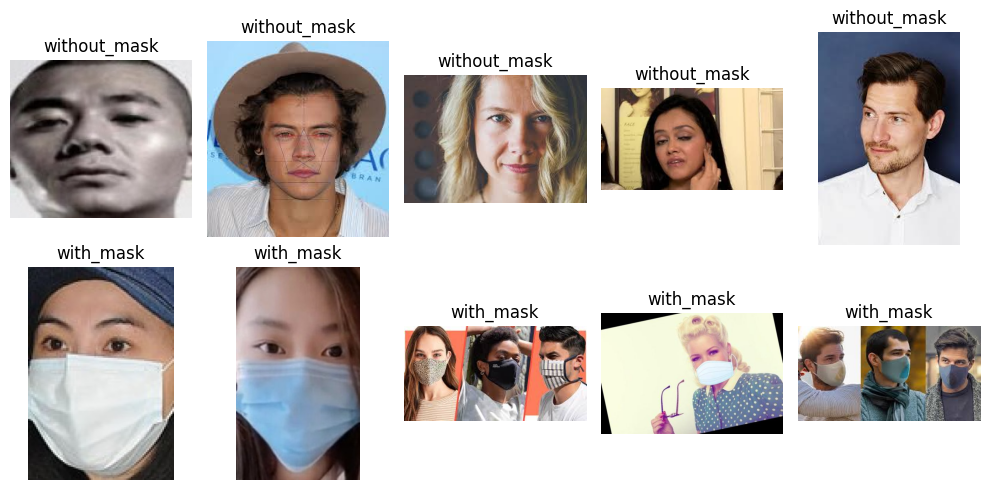

In [10]:
import os
import matplotlib.pyplot as plt
import cv2

# Classes folder
classes = os.listdir(data_dir)

plt.figure(figsize=(10,5))

img_count = 0

for category in classes:
    category_path = os.path.join(data_dir, category)

    # Take first 5 images from each class
    for img_name in os.listdir(category_path)[:5]:
        img_path = os.path.join(category_path, img_name)

        # Read image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Plot
        plt.subplot(2, 5, img_count + 1)
        plt.imshow(img)
        plt.title(category)
        plt.axis("off")

        img_count += 1

plt.tight_layout()
plt.show()

##4.Data Augmentation

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 128
BATCH_SIZE = 32

# Training (Augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

# Validation & Test (Only Rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)

# Train Generator
train_data = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filename',
    y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

# Validation Generator
val_data = test_datagen.flow_from_dataframe(
    val_df,
    x_col='filename',
    y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

# Test Generator
test_data = test_datagen.flow_from_dataframe(
    test_df,
    x_col='filename',
    y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 5287 validated image filenames belonging to 2 classes.
Found 1133 validated image filenames belonging to 2 classes.
Found 1133 validated image filenames belonging to 2 classes.


##5.Build CNN Model

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')  # Binary output
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##6.Model Training

In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

EPOCHS = 10

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
105/166 ━━━━━━━━━━━━━━━━━━━━ 1:11 1s/step - accuracy: 0.6926 - loss: 0.5578

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


166/166 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.8298 - loss: 0.3808 - val_accuracy: 0.8870 - val_loss: 0.2774
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.8850 - loss: 0.2776 - val_accuracy: 0.9038 - val_loss: 0.2368
Epoch 3/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.9001 - loss: 0.2534 - val_accuracy: 0.9117 - val_loss: 0.2183
Epoch 4/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - accuracy: 0.9075 - loss: 0.2224 - val_accuracy: 0.9320 - val_loss: 0.1643
Epoch 5/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.9128 - loss: 0.2089 - val_accuracy: 0.9223 - val_loss: 0.1936
Epoch 6/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 184s 1s/step - accuracy: 0.9270 - loss: 0.1847 - val_accuracy: 0.9126 - val_loss: 0.2011
Epoch 7/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.9313 - loss: 0.1769 - val_accuracy: 0.9515 - val_loss: 0.1347
Epoch 8/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.9372 - loss: 0.1672 - val_accuracy: 0.941

##7.Model Evaluation

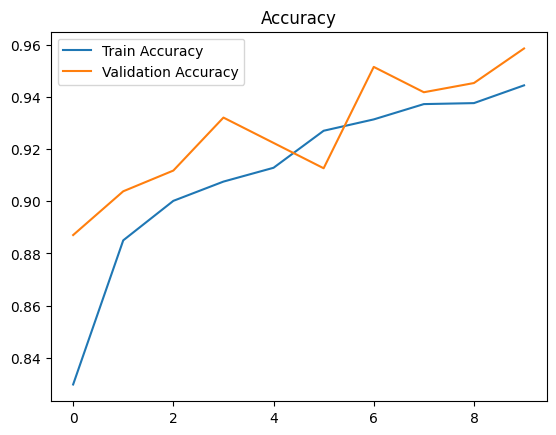

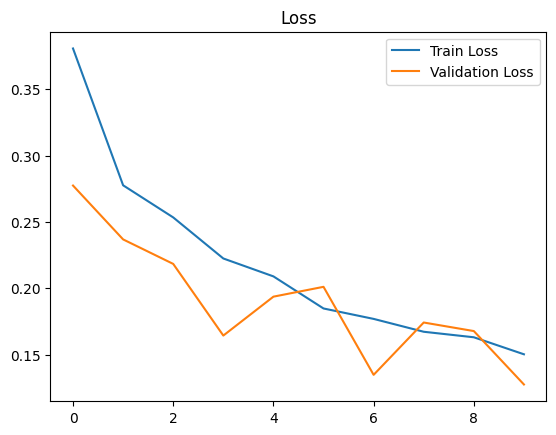

In [14]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.show()


In [15]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 284ms/step - accuracy: 0.9541 - loss: 0.1316
Test Accuracy: 0.9541041254997253


In [16]:
import numpy as np

pred = model.predict(test_data)
y_pred = (pred > 0.5).astype(int)

36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 283ms/step


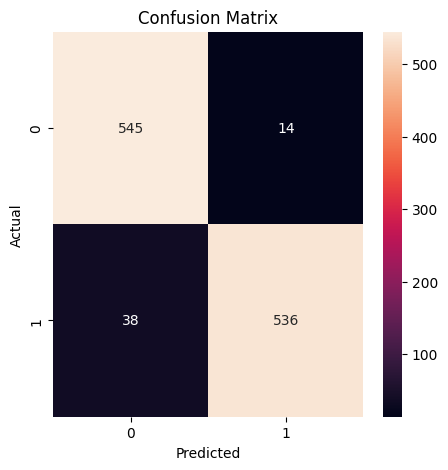

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_data.classes, y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [18]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(test_data.classes, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       559
           1       0.97      0.93      0.95       574

    accuracy                           0.95      1133
   macro avg       0.95      0.95      0.95      1133
weighted avg       0.95      0.95      0.95      1133

